In [1]:
from google.colab import files
uploaded = files.upload()


Saving Atal_Jal_Disclosed_Ground_Water_Level-2015-2022 (1).csv to Atal_Jal_Disclosed_Ground_Water_Level-2015-2022 (1).csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FILENAME = "Atal_Jal_Disclosed_Ground_Water_Level-2015-2022 (1).csv"
df_raw = pd.read_csv(FILENAME, encoding="latin1")

print("Shape:", df_raw.shape)
df_raw.head()

Shape: (5490, 30)


,Sr. No.,State_Name_With_LGD_Code,District_Name_With_LGD_Code,Block_Name_With_LGD_Code,GP_Name_With_LGD_Code,Village,Site_Name,TYPE,SOURCE,Well_ID,...,Pre-monsoon_2018 (meters below ground level),Post-monsoon_2018 (meters below ground level),Pre-monsoon_2019 (meters below ground level),Post-monsoon_2019 (meters below ground level),Pre-monsoon_2020 (meters below ground level),Post-monsoon_2020 (meters below ground level),Pre-monsoon_2021 (meters below ground level),Post-monsoon_2021 (meters below ground level),Pre-monsoon_2022 (meters below ground level),Post-monsoon_2022 (meters below ground level)
0,1,Gujarat_24,Banaskantha_441,Dantiwada_3735,NaN,Deri,Deri,Piezometer,SGWD,G_1_BK_021,...,8.1,13.55,24.4,11.2,13.35,3.1,20.80,16.90,20.2,12.3
1,2,Gujarat_24,Banaskantha_441,Dantiwada_3735,Akoli_155943,Akoli,Akoli,Piezometer,SGWD,G_1_BK_018,...,15.8,21.30,55.6,49.4,57.10,34.1,58.20,49.45,51.4,46.4
2,3,Gujarat_24,Banaskantha_441,Dantiwada_3735,Bhadli Kotha_155946,Bhadli kotha,Bhadli kotha,Piezometer,SGWD,G_1_BK_019,...,27.7,21.60,27.5,21.2,20.00,19.1,19.45,18.15,Dry,Dry
3,4,Gujarat_24,Banaskantha_441,Dantiwada_3735,Dantiwada_155954,Dantiwada,Dantiwada,Piezometer,SGWD,G_1_BK_020,...,8.6,7.85,11.1,10.2,8.80,2.7,10.80,6.80,12.4,6.45
4,5,Gujarat_24,Banaskantha_441,Dantiwada_3735,Gundari_155956,Gundari,Gundari,Dug Well,SGWD,BK-105,...,15.2,11.20,17.3,13.9,16.00,10.0,22.20,19.80,21.6,20.3


In [3]:
!ls


'Atal_Jal_Disclosed_Ground_Water_Level-2015-2022 (1).csv'   sample_data


In [5]:
df = df_raw[['State_Name_With_LGD_Code',
             'Pre-monsoon_2015 (meters below ground level)', 'Post-monsoon_2015 (meters below ground level)',
             'Pre-monsoon_2016 (meters below ground level)', 'Post-monsoon_2016 (meters below ground level)',
             'Pre-monsoon_2017 (meters below ground level)', 'Post-monsoon_2017 (meters below ground level)',
             'Pre-monsoon_2018 (meters below ground level)', 'Post-monsoon_2018 (meters below ground level)',
             'Pre-monsoon_2019 (meters below ground level)', 'Post-monsoon_2019 (meters below ground level)',
             'Pre-monsoon_2020 (meters below ground level)', 'Post-monsoon_2020 (meters below ground level)',
             'Pre-monsoon_2021 (meters below ground level)', 'Post-monsoon_2021 (meters below ground level)',
             'Pre-monsoon_2022 (meters below ground level)', 'Post-monsoon_2022 (meters below ground level)']].copy()

rename_map = {'State_Name_With_LGD_Code': 'State'}
for year in range(2015, 2023):
    rename_map[f'Pre-monsoon_{year} (meters below ground level)'] = f'Pre_{year}'
    rename_map[f'Post-monsoon_{year} (meters below ground level)'] = f'Post_{year}'

df = df.rename(columns=rename_map)
df.columns.tolist()

['State',
 'Pre_2015',
 'Post_2015',
 'Pre_2016',
 'Post_2016',
 'Pre_2017',
 'Post_2017',
 'Pre_2018',
 'Post_2018',
 'Pre_2019',
 'Post_2019',
 'Pre_2020',
 'Post_2020',
 'Pre_2021',
 'Post_2021',
 'Pre_2022',
 'Post_2022']

In [7]:
import re

def clean_state_name(s):
    if pd.isna(s):
        return s
    return re.sub(r'_?\d+$', '', str(s)).strip()

df['State'] = df['State'].apply(clean_state_name)
df['State'].unique()

array(['Gujarat', 'Haryana', 'Karnataka', 'Madhya Pradesh', 'Maharashtra',
       'Rajasthan', 'Uttar Pradesh'], dtype=object)

In [9]:
value_cols = [c for c in df.columns if c.startswith('Pre_') or c.startswith('Post_')]

for col in value_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # 'Dry' -> NaN automatically

for col in value_cols:
    df.loc[(df[col] < 0) | (df[col] > 100), col] = np.nan

df[value_cols].describe()


,Pre_2015,Post_2015,Pre_2016,Post_2016,Pre_2017,Post_2017,Pre_2018,Post_2018,Pre_2019,Post_2019,Pre_2020,Post_2020,Pre_2021,Post_2021,Pre_2022,Post_2022
count,3035.000000,3072.000000,3059.000000,3121.000000,3136.000000,3202.000000,3145.000000,3256.000000,3058.00000,3147.000000,3024.000000,3206.000000,3155.000000,3595.000000,5043.000000,5195.000000
mean,20.133463,18.435527,21.546345,18.431477,21.690026,18.930381,21.639043,19.854297,23.59240,18.919685,22.222060,18.987785,22.832992,17.535318,21.218701,15.865334
std,18.590199,18.994645,18.670366,20.063199,19.588906,20.436632,19.396897,20.188750,19.85687,21.055482,20.774654,20.838851,20.888050,20.319081,19.256333,19.268615
min,0.040000,0.010000,0.600000,0.010000,0.010000,0.010000,0.260000,0.050000,0.52000,0.010000,0.170000,0.100000,0.120000,0.010000,0.000000,0.030000
25%,8.150000,5.827500,9.200000,4.250000,8.387500,4.650000,8.550000,5.945000,9.60000,4.050000,8.050000,4.170000,8.300000,3.665000,7.900000,3.450000
50%,13.000000,10.775000,14.300000,10.400000,13.800000,10.605000,13.950000,11.635000,15.56000,9.800000,14.025000,10.500000,14.330000,9.130000,14.200000,7.370000
75%,25.260000,23.862500,28.100000,25.600000,29.212500,25.600000,28.250000,26.850000,32.70750,26.795000,29.025000,25.980000,30.550000,23.150000,27.400000,21.005000
max,100.000000,100.000000,99.900000,100.000000,100.000000,100.000000,100.000000,99.700000,99.75000,99.600000,99.900000,100.000000,100.000000,99.800000,100.000000,100.000000


In [10]:
long_rows = []
for col in value_cols:
    season, year = col.split('_')
    temp = df[['State', col]].rename(columns={col: 'Depth'})
    temp['Season'] = season
    temp['Year'] = int(year)
    long_rows.append(temp)

df_long = pd.concat(long_rows, ignore_index=True)
df_long = df_long.dropna(subset=['Depth'])
df_long.head()

,State,Depth,Season,Year
0,Gujarat,16.3,Pre,2015
1,Gujarat,15.4,Pre,2015
2,Gujarat,22.1,Pre,2015
3,Gujarat,12.9,Pre,2015
4,Gujarat,16.7,Pre,2015


In [11]:
state_year_avg = df_long.groupby(['State', 'Year', 'Season'])['Depth'].mean().reset_index()
national_avg = df_long.groupby(['Year', 'Season'])['Depth'].mean().reset_index()
national_avg

,Year,Season,Depth
0,2015,Post,18.435527
1,2015,Pre,20.133463
2,2016,Post,18.431477
3,2016,Pre,21.546345
4,2017,Post,18.930381
5,2017,Pre,21.690026
6,2018,Post,19.854297
7,2018,Pre,21.639043
8,2019,Post,18.919685
9,2019,Pre,23.592400


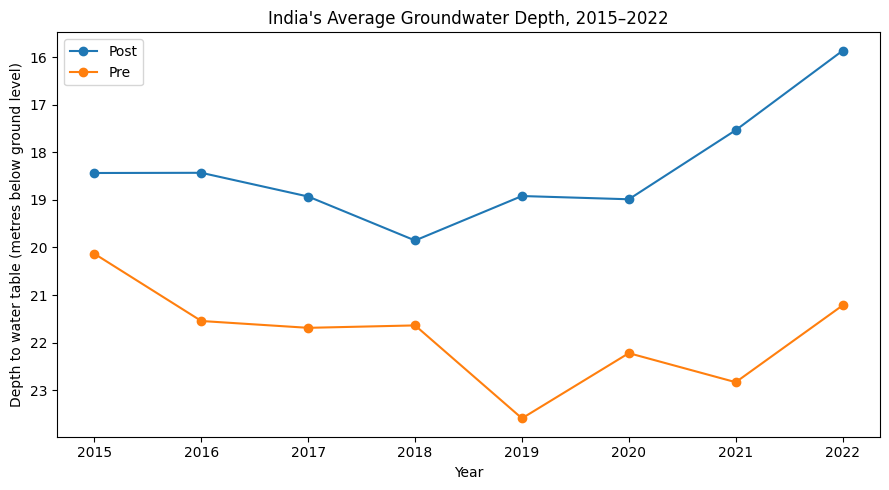

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
for season, group in national_avg.groupby('Season'):
    ax.plot(group['Year'], group['Depth'], marker='o', label=season)

ax.invert_yaxis()  # depth zyada = paani neeche, isliye axis ulta kiya taaki "upar jaana" = "sthiti kharab hona" dikhe
ax.set_xlabel('Year')
ax.set_ylabel('Depth to water table (metres below ground level)')
ax.set_title("India's Average Groundwater Depth, 2015–2022")
ax.legend()
plt.tight_layout()
plt.show()

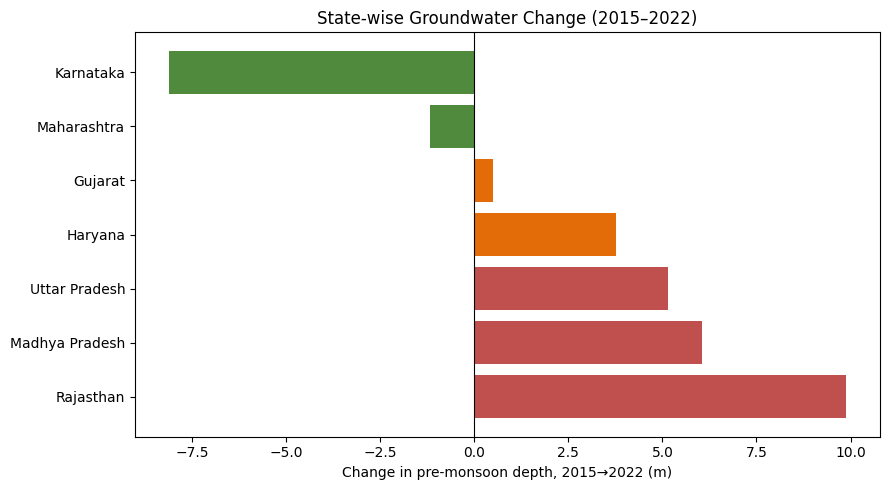

State
Rajasthan         9.883464
Madhya Pradesh    6.056462
Uttar Pradesh     5.151824
Haryana           3.772782
Gujarat           0.483630
Maharashtra      -1.175038
Karnataka        -8.124330
Name: Depth, dtype: float64


In [13]:
pre = state_year_avg[state_year_avg['Season'] == 'Pre']
change = pre[pre['Year'] == 2022].set_index('State')['Depth'] - pre[pre['Year'] == 2015].set_index('State')['Depth']
change = change.sort_values(ascending=False)

colors = ['#C0504D' if v > 5 else '#E36C09' if v > 0 else '#4F8A3D' for v in change]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(change.index, change.values, color=colors)
ax.set_xlabel('Change in pre-monsoon depth, 2015→2022 (m)')
ax.set_title('State-wise Groundwater Change (2015–2022)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(change)

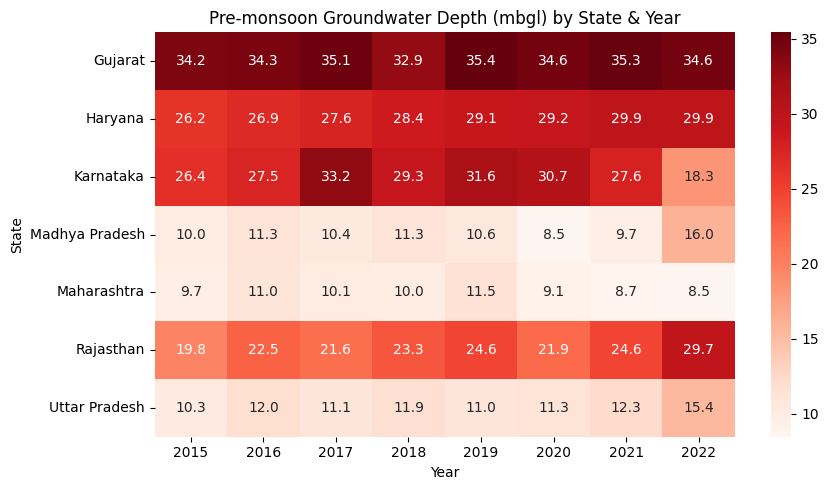

In [14]:
pivot = pre.pivot(index='State', columns='Year', values='Depth')

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, cmap='Reds', annot=True, fmt='.1f', ax=ax)
ax.set_title('Pre-monsoon Groundwater Depth (mbgl) by State & Year')
plt.tight_layout()
plt.show()

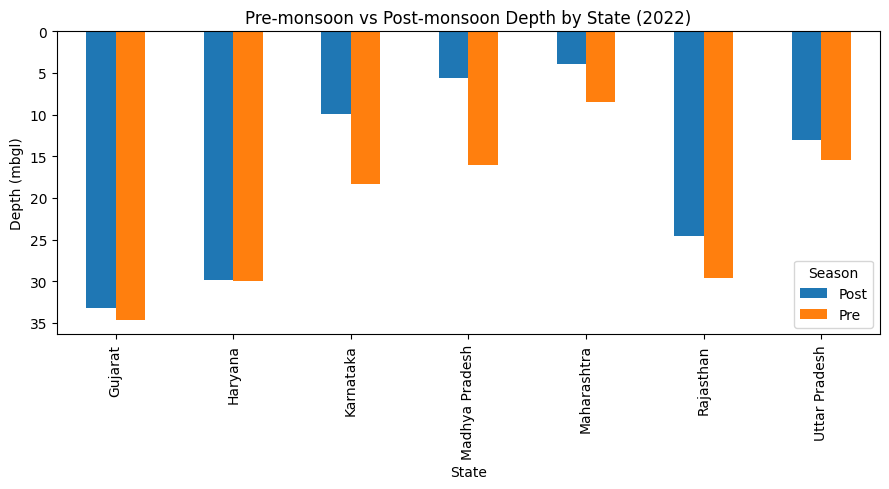

In [15]:
y2022 = state_year_avg[state_year_avg['Year'] == 2022]
pivot_2022 = y2022.pivot(index='State', columns='Season', values='Depth')

fig, ax = plt.subplots(figsize=(9, 5))
pivot_2022.plot(kind='bar', ax=ax)
ax.invert_yaxis()
ax.set_ylabel('Depth (mbgl)')
ax.set_title('Pre-monsoon vs Post-monsoon Depth by State (2022)')
plt.tight_layout()
plt.show()

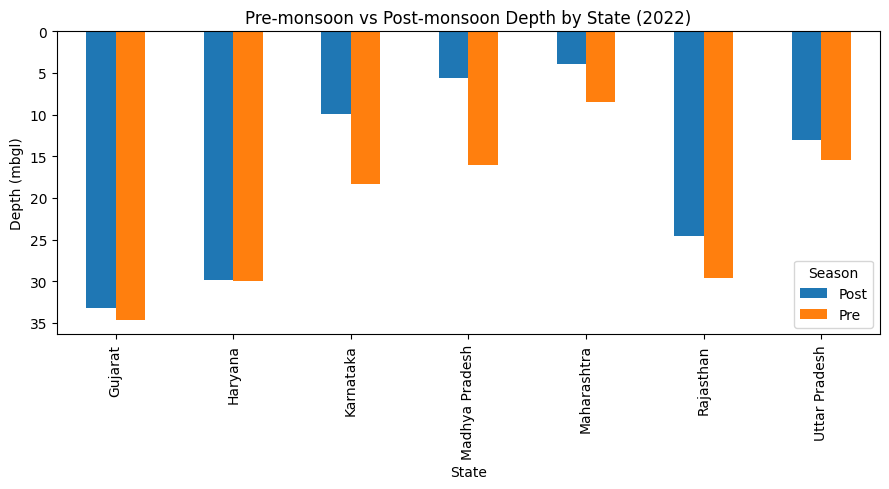

In [16]:
y2022 = state_year_avg[state_year_avg['Year'] == 2022]
pivot_2022 = y2022.pivot(index='State', columns='Season', values='Depth')

fig, ax = plt.subplots(figsize=(9, 5))
pivot_2022.plot(kind='bar', ax=ax)
ax.invert_yaxis()
ax.set_ylabel('Depth (mbgl)')
ax.set_title('Pre-monsoon vs Post-monsoon Depth by State (2022)')
plt.tight_layout()
plt.show()

In [17]:
summary = df_long.groupby('Season')['Depth'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
summary

,count,mean,median,std,min,max
Season,,,,,,
Post,27794,18.179975,9.94,20.137662,0.01,100.0
Pre,26655,21.815011,14.11,19.639131,0.00,100.0


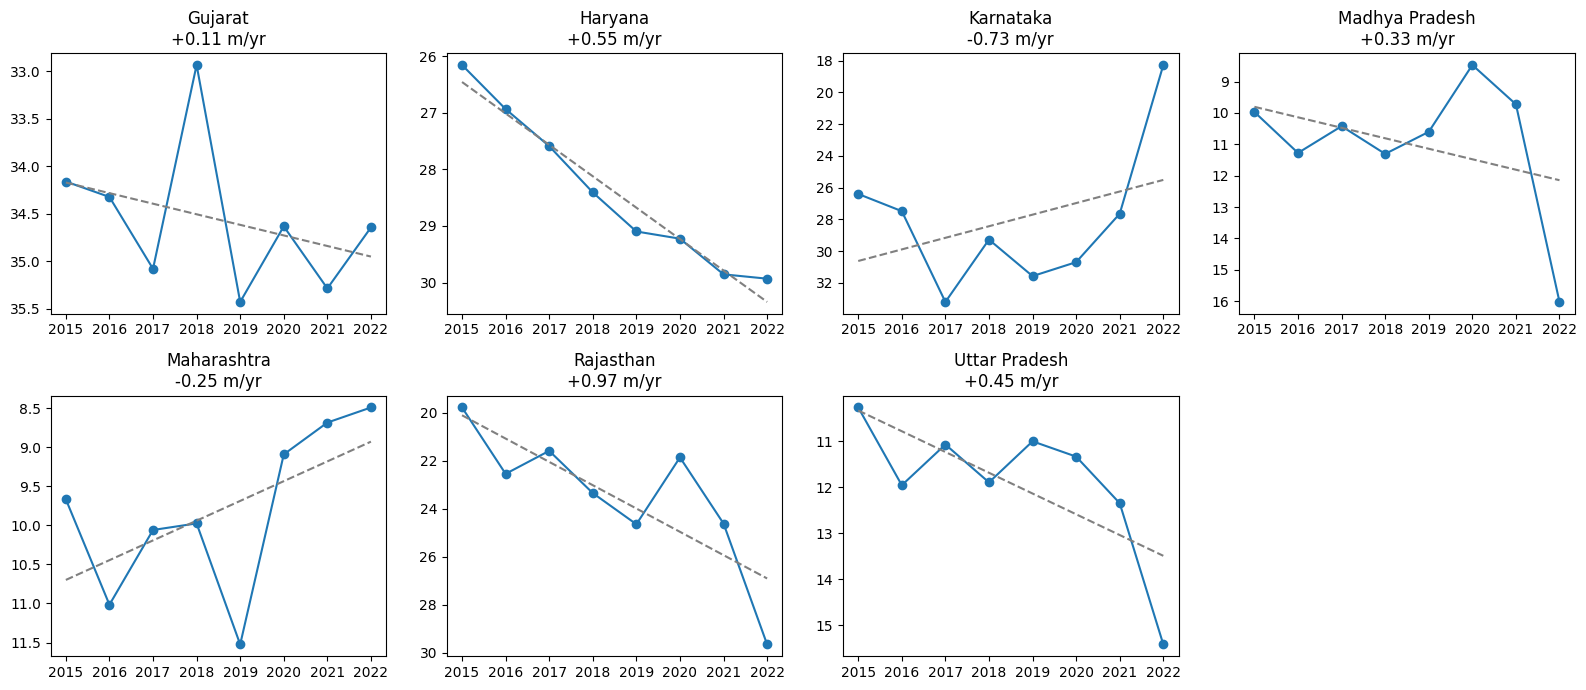

In [18]:
states = pre['State'].unique()
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.flatten()

for i, state in enumerate(states):
    sub = pre[pre['State'] == state].sort_values('Year')
    x, y = sub['Year'].values, sub['Depth'].values
    slope, intercept = np.polyfit(x, y, 1)

    ax = axes[i]
    ax.plot(x, y, marker='o')
    ax.plot(x, slope * x + intercept, linestyle='--', color='gray')
    ax.invert_yaxis()
    ax.set_title(f"{state}\n{slope:+.2f} m/yr")

for j in range(len(states), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()